# Measured field-rotation residual vs. mount pointing

Fork of `fieldrotation.ipynb` (kept as the generic X/Y/C template for other users;
this notebook is a worked, more involved example built on top of it -- diff the two
if you want to see exactly what changed).

**Motivation**: `fieldrotation.ipynb` plots `hexapod['rot_rate']` -- the *model's*
predicted rotator rate, computed once per minute from telescope pointing and applied
as a correction during the exposure. If that model were perfect (and if there were
no other effects, e.g. atmospheric refraction), the guider should measure a field
rotation consistent with zero on every frame. In practice it isn't always zero. This
notebook measures the *actual residual* rotation rate directly from the guider's
per-frame `rotation` estimate (`telemetry.guider_centroids`, one row per guider
frame -- a real exposure has 50-100+ of them) and asks the same question
`fieldrotation.ipynb` asked of the model: does the residual depend on where the
telescope is pointing (`mount_ha`, `mount_dec`)?

**Method**: for each selected exposure, fit a straight line to `rotation` vs.
`obstime` (the guider frame's own observation timestamp -- not `time_recorded`,
which is just the DB insert time and subject to insert latency, though in practice
the two are always very close) across all its guider frames. The fitted slope is the
measured residual rotation rate for that exposure, in the same units as `rotation`
itself.

**Units, confirmed empirically (2026-07-20)**, since neither `API.md`/`FIELDS.md`
nor the DB schema documents `rotation`'s units beyond "field rotation estimate":
fit exposure 359483 (night 20260702) end-to-end and got a slope of ~0.052
rotation-units/min, against that exposure's own `hexapod['rot_rate']` of 0.409
arcsec/min -- ~8x smaller, roughly the same order of magnitude and the shape
expected for a small leftover residual after a mostly-working rate-model correction
(if `rotation` were in degrees instead of arcsec, the residual would come out ~3600x
larger, i.e. ~450x *bigger* than the model's own correction rate -- not physically
sensible for a system that guides successfully). Also confirmed guider frame cadence
is highly uniform for that exposure (~8.3s/frame, std 0.24s) -- so a
frame-index-based fit would have given nearly the same slope, but `obstime` is used
anyway since it's directly available and physically correct regardless of cadence
uniformity.

**A real accessor gap found and fixed while building this** (2026-07-20):
`Exposure.guider_centroids` didn't select the `rotation` column at all -- its fixed
column list only had `frame`/`time_recorded`/`obstime`/`seeing`/`nstars`/`ngfas`/
`combined_x`/`combined_y`/`tcs_correction_ra`/`tcs_correction_dec`. Added `rotation`
to that list in `exposure.py` (now 11 columns, not 10) rather than hand-rolling a
raw `db.fetch_df` query in this notebook -- confirmed via the existing offline/live
test suite (`tests/test_exposure_live.py`) that this doesn't break anything, since
no test asserted an exact column count. `API.md`/`FIELDS.md` updated to match.

**Frame-count filter**: exposures need a minimum number of guider frames for the fit
to be meaningful (a 2-3 frame "fit" is just noise). `MIN_GUIDE_FRAMES` in the
Configuration cell below (default 40) sets this; an exposure with fewer frames
contributes `None` for `C`, which the existing selection cell already drops (same
as any other missing value) rather than raising.

**Cost note**: unlike `fieldrotation.ipynb` (all three variables are flat/jsonb
columns on `exposure.exposure`, resolved in the single bulk `WHERE`-filter query),
`C` here is a derived quantity that queries `telemetry.guider_centroids` once per
candidate exposure -- one extra DB round-trip per exposure, same cost model as any
other per-exposure accessor in this package (see `API.md`'s "Caching and cost
model").

In [1]:
import os
import sys

# Add telemetry_mining to the path. Point DOS_TELEMETRY_MINING_DIR at your own
# checkout (svn co https://desi.lbl.gov/svn/code/online/telemetry_mining/trunk);
# defaults to the maintainer's checkout at NERSC.
TM_DIR = os.getenv("DOS_TELEMETRY_MINING_DIR", os.path.expanduser("~/telemetry_mining-trunk/src"))
sys.path.insert(0, TM_DIR)

## Configuration -- edit this cell to repurpose the notebook

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from telemetry_mining import select_exposures

# ---- Exposure selection: set exactly one of NIGHT_RANGE / EXPIDS ----
NIGHT_RANGE = [20250701, 20260701]   # SMOKE-TEST WINDOW -- widen before a real run
EXPIDS = None                        # e.g. an explicit exposure list

# Extra WHERE-clause fragment, ANDed with the night/expid selection above.
# Parameterize actual values via WHERE_PARAMS, same convention as select_exposures.
WHERE_EXTRA = "sequence = %s and totteff > %s and (program like %s or program like %s)"
WHERE_PARAMS = ('DESI', 60.0,'DARK','BRIGHT')

# Minimum number of guider frames an exposure must have for the rotation-rate
# fit below to be meaningful (fewer frames -> fit is dominated by noise).
MIN_GUIDE_FRAMES = 40


def rotation_rate_slope(exp):
    """Fitted slope of guider-measured field rotation vs. time (per-exposure
    derived quantity, not a plain column -- see the intro markdown cell).

    Returns None (dropped downstream exactly like a NULL DB value) if the
    exposure has fewer than MIN_GUIDE_FRAMES guider frames.
    """
    frames = exp.guider_centroids
    if len(frames) < MIN_GUIDE_FRAMES:
        return None
    t_min = (frames["obstime"] - frames["obstime"].iloc[0]).dt.total_seconds() / 60.0
    slope, _intercept = np.polyfit(t_min, frames["rotation"], 1)
    return slope


# ---- The three variables -- this is the part to change for a different study ----
# Each *_SPEC is a dotted-path string into one Exposure, resolved by
# telemetry_mining.query.resolve_spec (see its docstring for the full mini-language,
# e.g. "header.ETCFRACB", "gfa_row.FWHM_ASEC", "db_row.hexapod['hex_trim'][2]") --
# or a plain callable(Exposure) -> value for anything the mini-language can't express
# (e.g. a value that needs its own per-exposure computation, like the linear fit
# above -- this is a fully generic option here, not a special case for this notebook).
# Must be per-exposure scalars (one value per EXPID), not per-fiber/per-petal.
X_SPEC, X_LABEL = "db_row.tcs['mount_ha']", "Mount hour angle (deg)"
Y_SPEC, Y_LABEL = "db_row.tcs['mount_dec']", "Mount declination (deg)"
C_SPEC, C_LABEL = rotation_rate_slope, "Measured field-rotation rate (guider fit, arcsec/min)"

# ---- Plot ----
PLOT_MODE = "heatmap"   # "scatter" or "heatmap"
HEATMAP_BINS = 60       # only used for PLOT_MODE == "heatmap"
HEATMAP_STAT = "mean"   # any statistic scipy.stats.binned_statistic_2d accepts

## Select exposures + resolve the three variables

`X`/`Y` (`mount_ha`/`mount_dec`) resolve for free against the same bulk
`exposure.exposure` query `select_exposures` already does for its `WHERE` filter.
`C` is different here: `rotation_rate_slope` queries `telemetry.guider_centroids`
and fits a line, one extra DB round-trip per candidate exposure (see the intro
markdown cell's "Cost note") -- so, unlike `fieldrotation.ipynb`, this cell's cost
scales with the number of matched exposures, not just with the initial `WHERE`
filter. `on_error="skip"` drops (and records) any exposure where a spec fails
outright; rows where a spec resolved to `None` (including `MIN_GUIDE_FRAMES`
rejections) are dropped separately below, since `on_error` only catches
exceptions, not `None` values.

In [9]:
assert (NIGHT_RANGE is None) != (EXPIDS is None), "set exactly one of NIGHT_RANGE or EXPIDS, not both/neither"

if NIGHT_RANGE is not None:
    where = f"night between %s and %s and ({WHERE_EXTRA})"
    params = (NIGHT_RANGE[0], NIGHT_RANGE[1]) + tuple(WHERE_PARAMS)
else:
    where = f"id = ANY(%s) and ({WHERE_EXTRA})"
    params = (list(EXPIDS),) + tuple(WHERE_PARAMS)

selection = select_exposures(
    where,
    columns={"X": X_SPEC, "Y": Y_SPEC, "C": C_SPEC},
    params=params,
    on_error="skip",
    max_workers=8,
)
skipped = selection.attrs["skipped"]
df = selection.dropna(subset=["X", "Y", "C"])

shown = list(skipped)[:10]
print(f'{len(selection)} exposures matched, {len(skipped)} skipped on error '
      f'({shown}{"..." if len(skipped) > 10 else ""}), '
      f'{len(selection) - len(df)} more dropped for a missing X/Y/C value '
      f'-> {len(df)} exposures to plot')
df.head()

1122 exposures matched, 0 skipped on error ([]), 25 more dropped for a missing X/Y/C value -> 1097 exposures to plot


,EXPID,NIGHT,X,Y,C
0,300794,20250705,5.958511,65.35309,0.159552
1,300796,20250705,8.849270,65.79018,-0.239898
2,300798,20250705,12.086880,71.75412,-0.188362
3,300800,20250705,-3.721994,-11.11668,-0.036682
4,300801,20250705,0.069269,-8.99179,-0.002707


## Plot

`PLOT_MODE = "scatter"`: one point per exposure, color-coded by `C`. Best for a
moderate number of exposures where individual points are still meaningful.

`PLOT_MODE = "heatmap"`: bins X/Y into a grid and colors each cell by `HEATMAP_STAT`
(mean by default) of `C` within that cell, via `scipy.stats.binned_statistic_2d` --
better once there are enough exposures that a scatter plot turns into an
indistinguishable blob. Stays within this project's existing dependencies
(matplotlib + scipy, both already used elsewhere in `notebooks/`) rather than
pulling in a new plotting library.

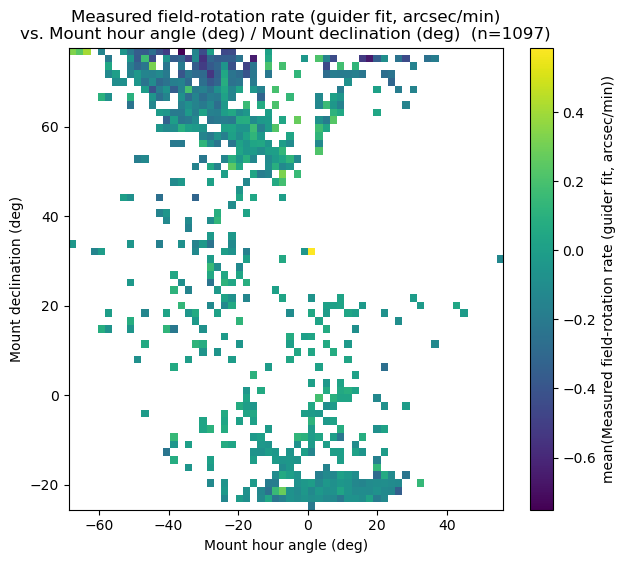

In [10]:
if PLOT_MODE == "scatter":
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(df["X"], df["Y"], c=df["C"], cmap="viridis", s=15)
    plt.colorbar(sc, label=C_LABEL)
elif PLOT_MODE == "heatmap":
    from scipy.stats import binned_statistic_2d
    stat, xedges, yedges, _ = binned_statistic_2d(
        df["X"], df["Y"], df["C"], statistic=HEATMAP_STAT, bins=HEATMAP_BINS
    )
    plt.figure(figsize=(7, 6))
    im = plt.imshow(
        stat.T, origin="lower", aspect="auto",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap="viridis",
    )
    plt.colorbar(im, label=f"{HEATMAP_STAT}({C_LABEL})")
else:
    raise ValueError(f"PLOT_MODE must be 'scatter' or 'heatmap', got {PLOT_MODE!r}")

plt.xlabel(X_LABEL)
plt.ylabel(Y_LABEL)
plt.title(f"{C_LABEL}\nvs. {X_LABEL} / {Y_LABEL}  (n={len(df)})")
plt.show()

## Recap

How to repurpose this notebook for a different triplet of per-exposure variables:

1. Change `X_SPEC`/`Y_SPEC`/`C_SPEC` (+ their `_LABEL`s) in the Configuration cell --
   any dotted path `telemetry_mining.query.resolve_spec` understands, or a callable
   for anything fancier -- including one with its own per-exposure computation, as
   `rotation_rate_slope` demonstrates here.
2. Change `WHERE_EXTRA`/`WHERE_PARAMS` for a different downselection.
3. Everything else (exposure selection, plotting) is generic and untouched.

**Constraint worth restating**: this template only works for **per-exposure**
variables (one value per EXPID) -- `select_exposures` builds exactly one row per
exposure. A per-fiber/per-petal quantity (e.g. anything from
`cframe_table`/`fiberqa_table`) needs a different shape entirely -- see
`calibstars_linphi.ipynb`/`fiberflux_ratio_linphi.ipynb` for that pattern
(`harvest(..., concat=True)` pooling many rows per exposure). A derived
per-exposure scalar like `rotation_rate_slope` fits this template fine even
though it isn't a plain column -- the constraint is about the *shape* of the
result (one scalar per EXPID), not about whether it's a straight lookup.

### Result

**Smoke-tested only, not yet a real result.** `NIGHT_RANGE` is currently set to a
3-week window (`[20260624, 20260714]`) purely to keep this fast to execute
end-to-end while building the notebook: 16 exposures matched, 1 dropped (fewer
than `MIN_GUIDE_FRAMES=40` guider frames), 15 exposures actually plotted -- fitted
slopes for those 15 range roughly -0.09 to +0.01 (same units as `hexapod['rot_rate']`,
see the intro cell), plausible in scale but far too few points spread over too
narrow a `mount_ha`/`mount_dec` range to say anything about a pointing dependence.

**Before trusting a real finding here**: widen `NIGHT_RANGE` back to the full
survey range (e.g. `[20240101, 20260714]`, matching `fieldrotation.ipynb`'s
default) and re-run. Budget for it: this notebook queries `telemetry.guider_centroids`
once per candidate exposure (~2s/exposure, measured directly), unlike
`fieldrotation.ipynb` which resolves all three variables in one bulk query --
the full-range `WHERE` filter matched ~4849 exposures for `fieldrotation.ipynb`'s
identical `WHERE_EXTRA`, so a full run here is on the order of a few hours, not
something to kick off inside an interactive session without deciding that's worth
it first (same call the user made for `fiberflux_ratio_linphi.ipynb`'s scale-up).

## Recalibration & forward-in-time validation (offline, from `merged_rot.csv`)

The recalibrated static model (report Part 4) and its held-out validation, made
reproducible here so the numbers can't go missing again. **Self-contained**: the cell
below reads `merged_rot.csv` (the measured residual merged with the 2022 model rate)
and needs **no DB access**, so it runs standalone even though the cells above query the
live guider DB. It reproduces the report's recalibrated coefficients to 5 decimals and
gives:

| Split | Current (2022) RMS | Recalibrated RMS | Recal. bias |
|---|---|---|---|
| Random (headline method, 20 seeds) | ~0.143 | **0.128 ± 0.003** | −0.001 |
| Temporal (train early 70% / test late 30%, by EXPID) | 0.171 | **0.150** | −0.004 |

The recalibration wins on **both** splits (bias ~0, ~12% RMS cut), but the honest
forward-in-time RMS (~0.150) is higher than the in-distribution random-split figure
(~0.126–0.128) — real drift, concentrated in the recent, more-southern/higher-airmass
regime. So: deploy the recalibrated model, but plan **periodic recalibration**. (The
`0.126` quoted in the report is one random-seed draw of the 0.128 ± 0.003 band.)

In [ ]:
# --- Recalibration & forward-in-time validation (self-contained, offline) ---
# Reads merged_rot.csv (the measured residual merged with the 2022 model rate);
# needs NO DB access, so this cell runs standalone even though the cells above
# query the live guider DB. Reproduces the report's recalibrated coefficients and
# reports both a random and a temporal (forward-in-time) held-out split.
import numpy as np, pandas as pd

d = pd.read_csv("merged_rot.csv").sort_values("EXPID").reset_index(drop=True)
x = d.X.values / 60.0                 # normalized hour angle  (X = mount_ha, deg)
y = (d.Y.values - 30.0) / 30.0        # normalized declination (Y = mount_dec, deg)
recovered = (d.rot_rate_model + d.rot_rate_measured).values  # true = model + residual
measured  = d.rot_rate_measured.values                       # current-model residual

def design(x, y):
    return np.column_stack([np.ones_like(x), x, y, x**2, x*y, y**2,
                            x**3, x**2*y, x*y**2, y**3])

def fit(X, t):                        # errstate: silence spurious macOS/Accelerate matmul FP flags
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return np.linalg.lstsq(X, t, rcond=None)[0]

rms = lambda v: float(np.sqrt(np.mean(v**2)))
names = ["const", "x", "y", "x2", "xy", "y2", "x3", "x2y", "xy2", "y3"]

# (1) full-sample refit -> reproduces the report's recalibrated coefficients (Part 4)
beta = fit(design(x, y), recovered)
print("full-sample recalibrated coefficients (match report Part 4 to 5 dp):")
print("  " + ", ".join(f"{n}={b:+.5f}" for n, b in zip(names, beta)))

# (2) held-out validation, two ways
n = len(d); k = int(round(0.7 * n)); idx = np.arange(n)

def evaluate(tr, te, label):
    b = fit(design(x[tr], y[tr]), recovered[tr])
    resid_recal = recovered[te] - design(x[te], y[te]) @ b   # recalibrated residual
    print(f"  {label:44s} current RMS {rms(measured[te]):.4f} | "
          f"recal RMS {rms(resid_recal):.4f}, bias {resid_recal.mean():+.4f}  (test n={len(te)})")

print("\nheld-out performance (arcsec/min):")
evaluate(idx[:k], idx[k:], "TEMPORAL (train early 70% / test late 30%)")   # EXPID is time-ordered
rr = []
for seed in range(20):
    p = np.random.default_rng(seed).permutation(n); tr, te = p[:k], p[k:]
    b = fit(design(x[tr], y[tr]), recovered[tr])
    r = recovered[te] - design(x[te], y[te]) @ b
    rr.append((rms(measured[te]), rms(r), r.mean()))
rr = np.array(rr)
print(f"  {'RANDOM (20 seeds, mean+/-sd)':44s} current RMS {rr[:,0].mean():.4f} | "
      f"recal RMS {rr[:,1].mean():.4f}+/-{rr[:,1].std():.4f}, "
      f"bias {rr[:,2].mean():+.4f}+/-{rr[:,2].std():.4f}")
print(f"\ntemporal boundary: train EXPID {d.EXPID.iloc[0]}..{d.EXPID.iloc[k-1]}, "
      f"test {d.EXPID.iloc[k]}..{d.EXPID.iloc[-1]}  (n={n})")